# Trader Performance vs Market Sentiment

This notebook analyzes whether trader performance and trading behavior change across different **Bitcoin market sentiment regimes** using:
- **Hyperliquid historical trader data**
- **Bitcoin Fear & Greed Index**

The goal is to answer three assignment questions:
1. Does trader performance change between Fear and Greed days?
2. Do traders change their behavior based on sentiment?
3. Which trader segments perform better, and what strategy ideas can be built from that?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('default')

In [2]:
import os

chart_folder = "charts"
os.makedirs(chart_folder, exist_ok=True)

## Part A — Data Preparation

In this section, I load both datasets, check their shape, missing values, and duplicates, then align them by **calendar date** so that each trade can be matched with the corresponding **Fear & Greed sentiment label**.


In [3]:
# load data
trades = pd.read_csv('data/raw/historical_data.csv')
sentiment = pd.read_csv('data/raw/fear_greed_index.csv')

print('Trades shape:', trades.shape)
print('Sentiment shape:', sentiment.shape)

print('\nMissing values in trades:')
print(trades.isna().sum())

print('\nMissing values in sentiment:')
print(sentiment.isna().sum())

print('\nDuplicate rows in trades:', trades.duplicated().sum())
print('Duplicate rows in sentiment:', sentiment.duplicated().sum())

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)

Missing values in trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0


### Convert timestamps and align by date

The trader file stores timestamps in **Timestamp IST**, so I first convert that column into a proper datetime format and then extract the **date** part.  
The sentiment file already contains a daily date field, so after converting both columns to the same format, I merge the two datasets on **date**.

This gives a trader-level dataset where every trade is tagged with the market sentiment of that day.


In [4]:
# Trade timestamps are given as dd-mm-yyyy HH:MM strings (IST) -> parse to real datetimes
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['datetime'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

print("Trade data date range:   ", trades['date'].min(), "to", trades['date'].max())
print("Sentiment data range:    ", sentiment['date'].min(), "to", sentiment['date'].max())

trade_dates = set(trades['date'])
sentiment_dates = set(sentiment['date'])
missing = sorted(trade_dates - sentiment_dates)
print("\nTrading days with no sentiment entry:", missing)
print(f"Date coverage: {len(trade_dates & sentiment_dates)} / {len(trade_dates)} trading days matched")

# Build a complete daily sentiment calendar and forward-fill the 1 missing day
# (Fear/Greed regimes persist for multiple days, so a same-regime carry-forward is a safe fill)
sent_full = sentiment.set_index('date').sort_index()
all_days = pd.date_range(sent_full.index.min(), sent_full.index.max()).date
sent_full = sent_full.reindex(all_days).ffill().rename_axis('date').reset_index()

Trade data date range:    2023-05-01 to 2025-05-01
Sentiment data range:     2018-02-01 to 2025-05-02

Trading days with no sentiment entry: [datetime.date(2024, 10, 26)]
Date coverage: 479 / 480 trading days matched


In [5]:
# Merge trades with the completed sentiment calendar
df = trades.merge(
    sent_full[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged data shape:", df.shape)
df[['Account', 'date', 'classification']].head()

Merged data shape: (211224, 19)


,Account,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-12-02,Extreme Greed


### Create metrics

To compare performance and behavior across sentiment regimes, I create **trader-day level metrics**:

- **daily_pnl** → total closed PnL per trader per day  
- **win_rate** → percentage of profitable trades per trader-day  
- **avg_trade_size** → average trade size in USD  
- **trades_per_day** → number of trades taken by a trader on that day  
- **long_ratio** → share of trades that are long / buy positions  

These metrics will be used later for both the **sentiment analysis** and the **trader segmentation**.


In [6]:
# numeric columns
num_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# trade-level helper columns
df['is_win'] = (df['Closed PnL'] > 0).astype(int)
df['is_long'] = df['Side'].astype(str).str.contains('BUY|LONG', case=False, na=False).astype(int)

# trader-day metrics
daily = df.groupby(['Account', 'date', 'classification'], as_index=False).agg(
    daily_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    trades_per_day=('Closed PnL', 'size'),
    long_ratio=('is_long', 'mean')
)

# trader-level metrics for segmentation
trader = daily.groupby('Account', as_index=False).agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    total_pnl=('daily_pnl', 'sum'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_trades_per_day=('trades_per_day', 'mean'),
    pnl_std=('daily_pnl', 'std')
)
trader['pnl_std'] = trader['pnl_std'].fillna(0)

daily.head()

,Account,date,classification,daily_pnl,win_rate,avg_trade_size,trades_per_day,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,0.000000,5089.718249,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,0.000000,7976.664412,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,0.000000,23734.500000,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,0.000000,28186.666667,12,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,0.444444,17248.148148,27,0.444444


## Part B — Analysis

After building the trader-day dataset, I answer the three core analysis questions from the assignment:
1. **Performance comparison** across Fear vs Greed regimes  
2. **Behavior comparison** across sentiment regimes  
3. **Trader segmentation** to identify which trader types perform better


### 1) Does performance differ between Fear vs Greed days?

To answer this, I compare:
- **average daily PnL**
- **median daily PnL**
- **average win rate**

for each sentiment category.  
This helps show whether traders perform better during Fear, Greed, or other market moods.


In [7]:
perf = daily.groupby('classification').agg(
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    mean_win_rate=('win_rate', 'mean')
).sort_values('mean_daily_pnl', ascending=False)

perf

,mean_daily_pnl,median_daily_pnl,mean_win_rate
classification,,,
Fear,5328.818161,107.892532,0.364033
Extreme Greed,5161.922644,418.319862,0.386387
Extreme Fear,4619.439053,218.377399,0.329659
Neutral,3438.618818,167.551743,0.355414
Greed,3378.430304,159.201612,0.344570


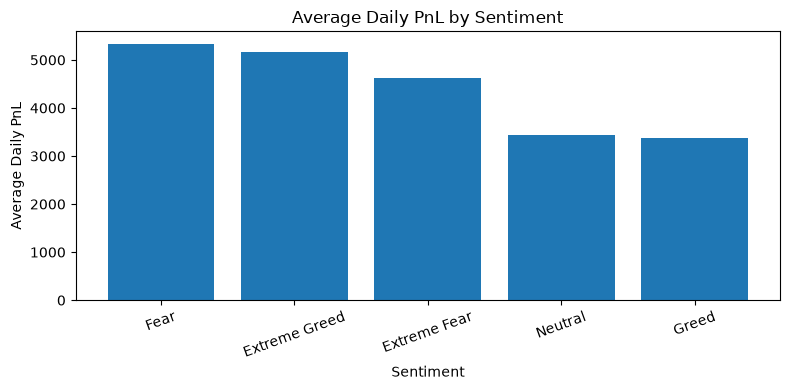

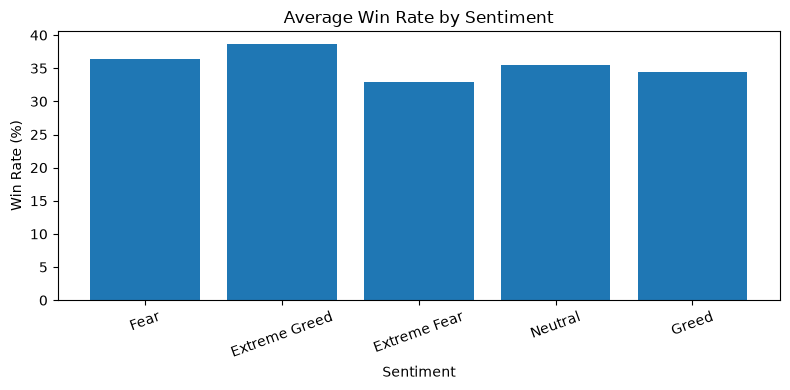

In [8]:
# Chart 1: average daily PnL by sentiment
plt.figure(figsize=(8,4))
plt.bar(perf.index.astype(str), perf['mean_daily_pnl'])
plt.title('Average Daily PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Daily PnL')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{chart_folder}/avg_daily_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 2: win rate by sentiment
plt.figure(figsize=(8,4))
plt.bar(perf.index.astype(str), perf['mean_win_rate']*100)
plt.title('Average Win Rate by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{chart_folder}/avg_win_rate_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

### 2) Do traders change behavior based on sentiment?

Here I compare trader behavior using:
- **average trade size**
- **average number of trades per day**
- **average long ratio**

If these metrics change across sentiment regimes, it suggests that traders adjust their risk-taking and trading style depending on market mood.


In [9]:
behavior = daily.groupby('classification').agg(
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_trades_per_day=('trades_per_day', 'mean'),
    avg_long_ratio=('long_ratio', 'mean')
).sort_values('avg_trade_size', ascending=False)

behavior

,avg_trade_size,avg_trades_per_day,avg_long_ratio
classification,,,
Fear,8975.928546,98.153968,0.518967
Neutral,6963.694861,100.228723,0.472431
Extreme Fear,6773.464125,133.750000,0.531533
Greed,6440.732968,77.517720,0.472408
Extreme Greed,5371.637182,76.030418,0.473116


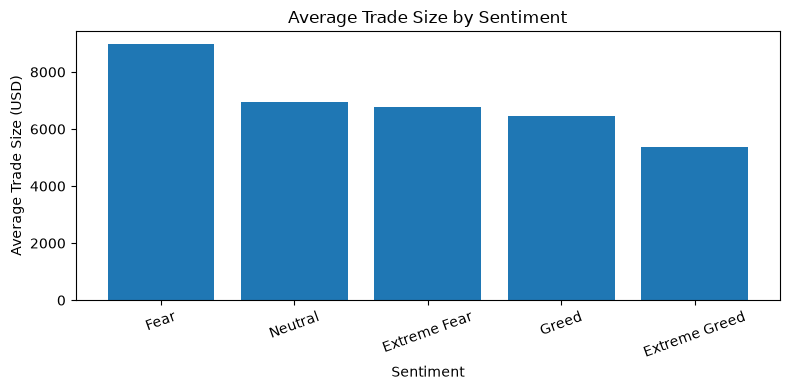

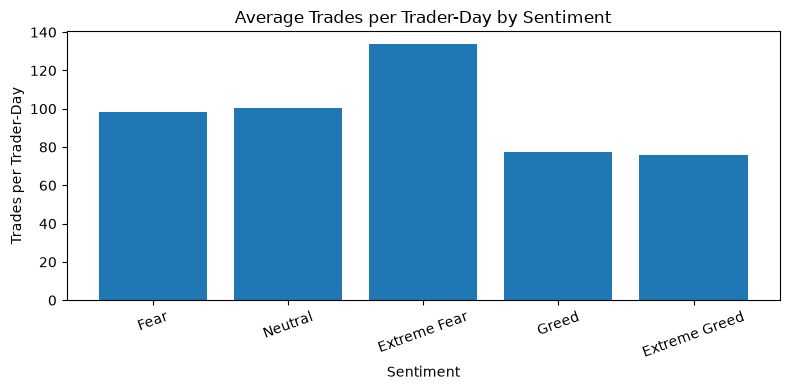

In [14]:
# Chart 3: average trade size by sentiment
plt.figure(figsize=(8,4))
plt.bar(behavior.index.astype(str), behavior['avg_trade_size'])
plt.title('Average Trade Size by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{chart_folder}/avg_trade_size_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 4: average trades per day by sentiment
plt.figure(figsize=(8,4))
plt.bar(behavior.index.astype(str), behavior['avg_trades_per_day'])
plt.title('Average Trades per Trader-Day by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Trades per Trader-Day')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{chart_folder}/avg_trades_per_day_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

### 3) Trader Segments

To make the analysis more actionable, I split traders into simple segments:

1. **Frequent vs Infrequent traders**  
   based on average trades per day

2. **High Size vs Low Size traders**  
   based on average trade size in USD

3. **Consistent vs Inconsistent traders**  
   based on the standard deviation of daily PnL  
   - lower volatility in daily PnL → more consistent  
   - higher volatility in daily PnL → more inconsistent

Then I compare average daily PnL across these groups.


In [11]:
# segment 1: frequent vs infrequent
trader['freq_segment'] = np.where(
    trader['avg_trades_per_day'] >= trader['avg_trades_per_day'].median(),
    'Frequent', 'Infrequent'
)

# segment 2: high-size vs low-size
trader['size_segment'] = np.where(
    trader['avg_trade_size'] >= trader['avg_trade_size'].median(),
    'High Size', 'Low Size'
)

# segment 3: consistent vs inconsistent
trader['consistency_segment'] = np.where(
    trader['pnl_std'] <= trader['pnl_std'].median(),
    'Consistent', 'Inconsistent'
)

trader.head()

,Account,avg_daily_pnl,total_pnl,avg_win_rate,avg_trade_size,avg_trades_per_day,pnl_std,freq_segment,size_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,1.600230e+06,0.352333,33569.102224,159.083333,150401.797346,Frequent,High Size,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,4.788532e+04,0.397134,4359.830930,140.000000,3603.042291,Frequent,Low Size,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,-7.043619e+04,0.379952,11057.118419,317.416667,33420.410014,Frequent,High Size,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,1.324648e+05,0.452509,484.844294,82.166667,2993.284702,Frequent,Low Size,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,1.686580e+05,0.498708,2553.757037,46.942029,4867.743469,Infrequent,Low Size,Consistent


In [12]:
# merge trader segments back to daily table
daily_seg = daily.merge(
    trader[['Account','freq_segment','size_segment','consistency_segment']],
    on='Account',
    how='left'
)

freq_summary = daily_seg.groupby('freq_segment')['daily_pnl'].mean().reset_index()
size_summary = daily_seg.groupby('size_segment')['daily_pnl'].mean().reset_index()
cons_summary = daily_seg.groupby('consistency_segment')['daily_pnl'].mean().reset_index()

print('Frequent vs Infrequent')
print(freq_summary)
print('\nHigh Size vs Low Size')
print(size_summary)
print('\nConsistent vs Inconsistent')
print(cons_summary)

Frequent vs Infrequent
  freq_segment    daily_pnl
0     Frequent  5939.703473
1   Infrequent  3179.269742

High Size vs Low Size
  size_segment    daily_pnl
0    High Size  5777.871478
1     Low Size  3607.818933

Consistent vs Inconsistent
  consistency_segment    daily_pnl
0          Consistent  1187.255291
1        Inconsistent  9193.213020


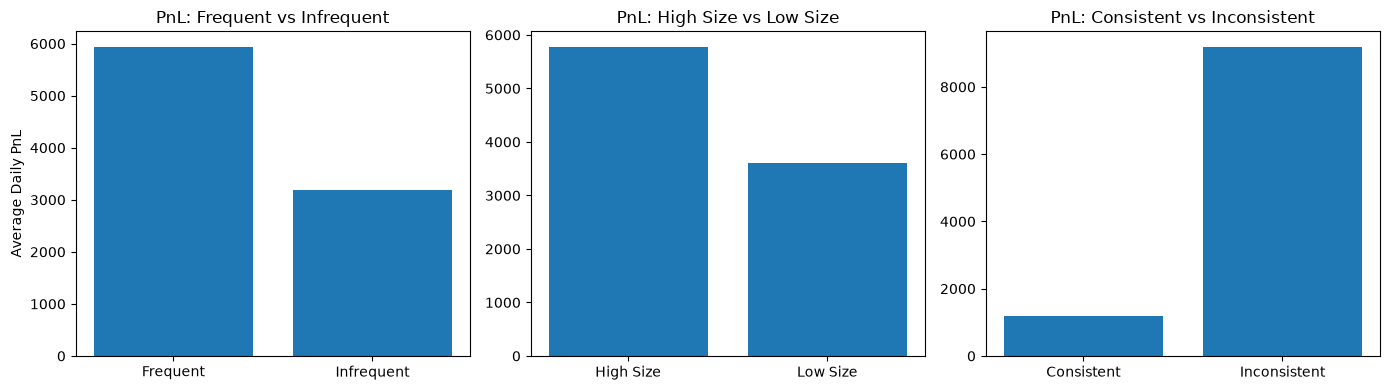

In [13]:
# Chart 5: average PnL by trader segment
fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].bar(freq_summary['freq_segment'], freq_summary['daily_pnl'])
axes[0].set_title('PnL: Frequent vs Infrequent')
axes[0].set_ylabel('Average Daily PnL')

axes[1].bar(size_summary['size_segment'], size_summary['daily_pnl'])
axes[1].set_title('PnL: High Size vs Low Size')

axes[2].bar(cons_summary['consistency_segment'], cons_summary['daily_pnl'])
axes[2].set_title('PnL: Consistent vs Inconsistent')

plt.tight_layout()
plt.savefig("charts/trader_segments_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 4) Insights

### Insight 1 — Performance changes across sentiment regimes
The performance table shows that **Fear days produced the highest average daily PnL (~5,329)** among the main Fear/Greed categories, while **Greed days had the weakest average daily PnL (~3,378)**.  
Extreme Greed also performed better than Greed in this sample, but overall the strongest profitability came during **Fear / high-stress conditions**.  
This suggests that volatile or fearful markets may create better short-term trading opportunities for active traders.

### Insight 2 — Traders become more aggressive when sentiment weakens
The behavior table shows that **Fear days had the largest average trade size (~$8,976)**, clearly above Greed (~$6,441) and Extreme Greed (~$5,372).  
Trade frequency was also relatively high during **Fear** and **Neutral** days, while Greed and Extreme Greed saw lower average trades per trader-day.  
This indicates that traders were generally **more aggressive in sizing and activity during fearful conditions** rather than becoming defensive.

### Insight 3 — Frequent traders outperform infrequent traders
The segment analysis shows that **Frequent traders generated much higher average daily PnL (~5,940)** compared with **Infrequent traders (~3,180)**.  
High-size traders also outperformed low-size traders on average PnL, but the clearest difference came from **trading activity**.  
So in this sample, the strongest trader profile is not simply “bigger trades”, but **traders who participate more actively and consistently capture more opportunities**.

### Segment takeaway
- **Frequent > Infrequent** in average daily PnL  
- **High Size > Low Size** in average daily PnL  
- **Inconsistent traders showed higher average PnL than consistent traders**, which likely means they are taking more volatile bets. This can improve returns, but it also implies higher risk and less stable performance.


## Part C — Actionable Output

### Strategy idea 1 — Use sentiment as a participation filter
Since **Fear days show stronger average PnL and larger trade sizes**, sentiment can be used as a context signal.  
A simple rule could be:

> **During Fear days, allow higher trading activity only for traders who already belong to the strong-performing segment (especially frequent traders).**

This keeps the strategy selective instead of increasing risk for everyone.

### Strategy idea 2 — Prioritize active traders over simply large traders
The segment results show that **Frequent traders outperform Infrequent traders by a wide margin**, while high trade size alone is not enough to explain performance.  
So a practical rule is:

> **Increase exposure first for active traders with a good recent PnL profile, rather than increasing size for all traders equally.**

This makes the strategy more robust because it combines **sentiment + trader behavior** instead of relying on just one signal.
